# Water Potability EDA

In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('./water_potability.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [74]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [75]:
df.isna().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

## Univariate Analysis

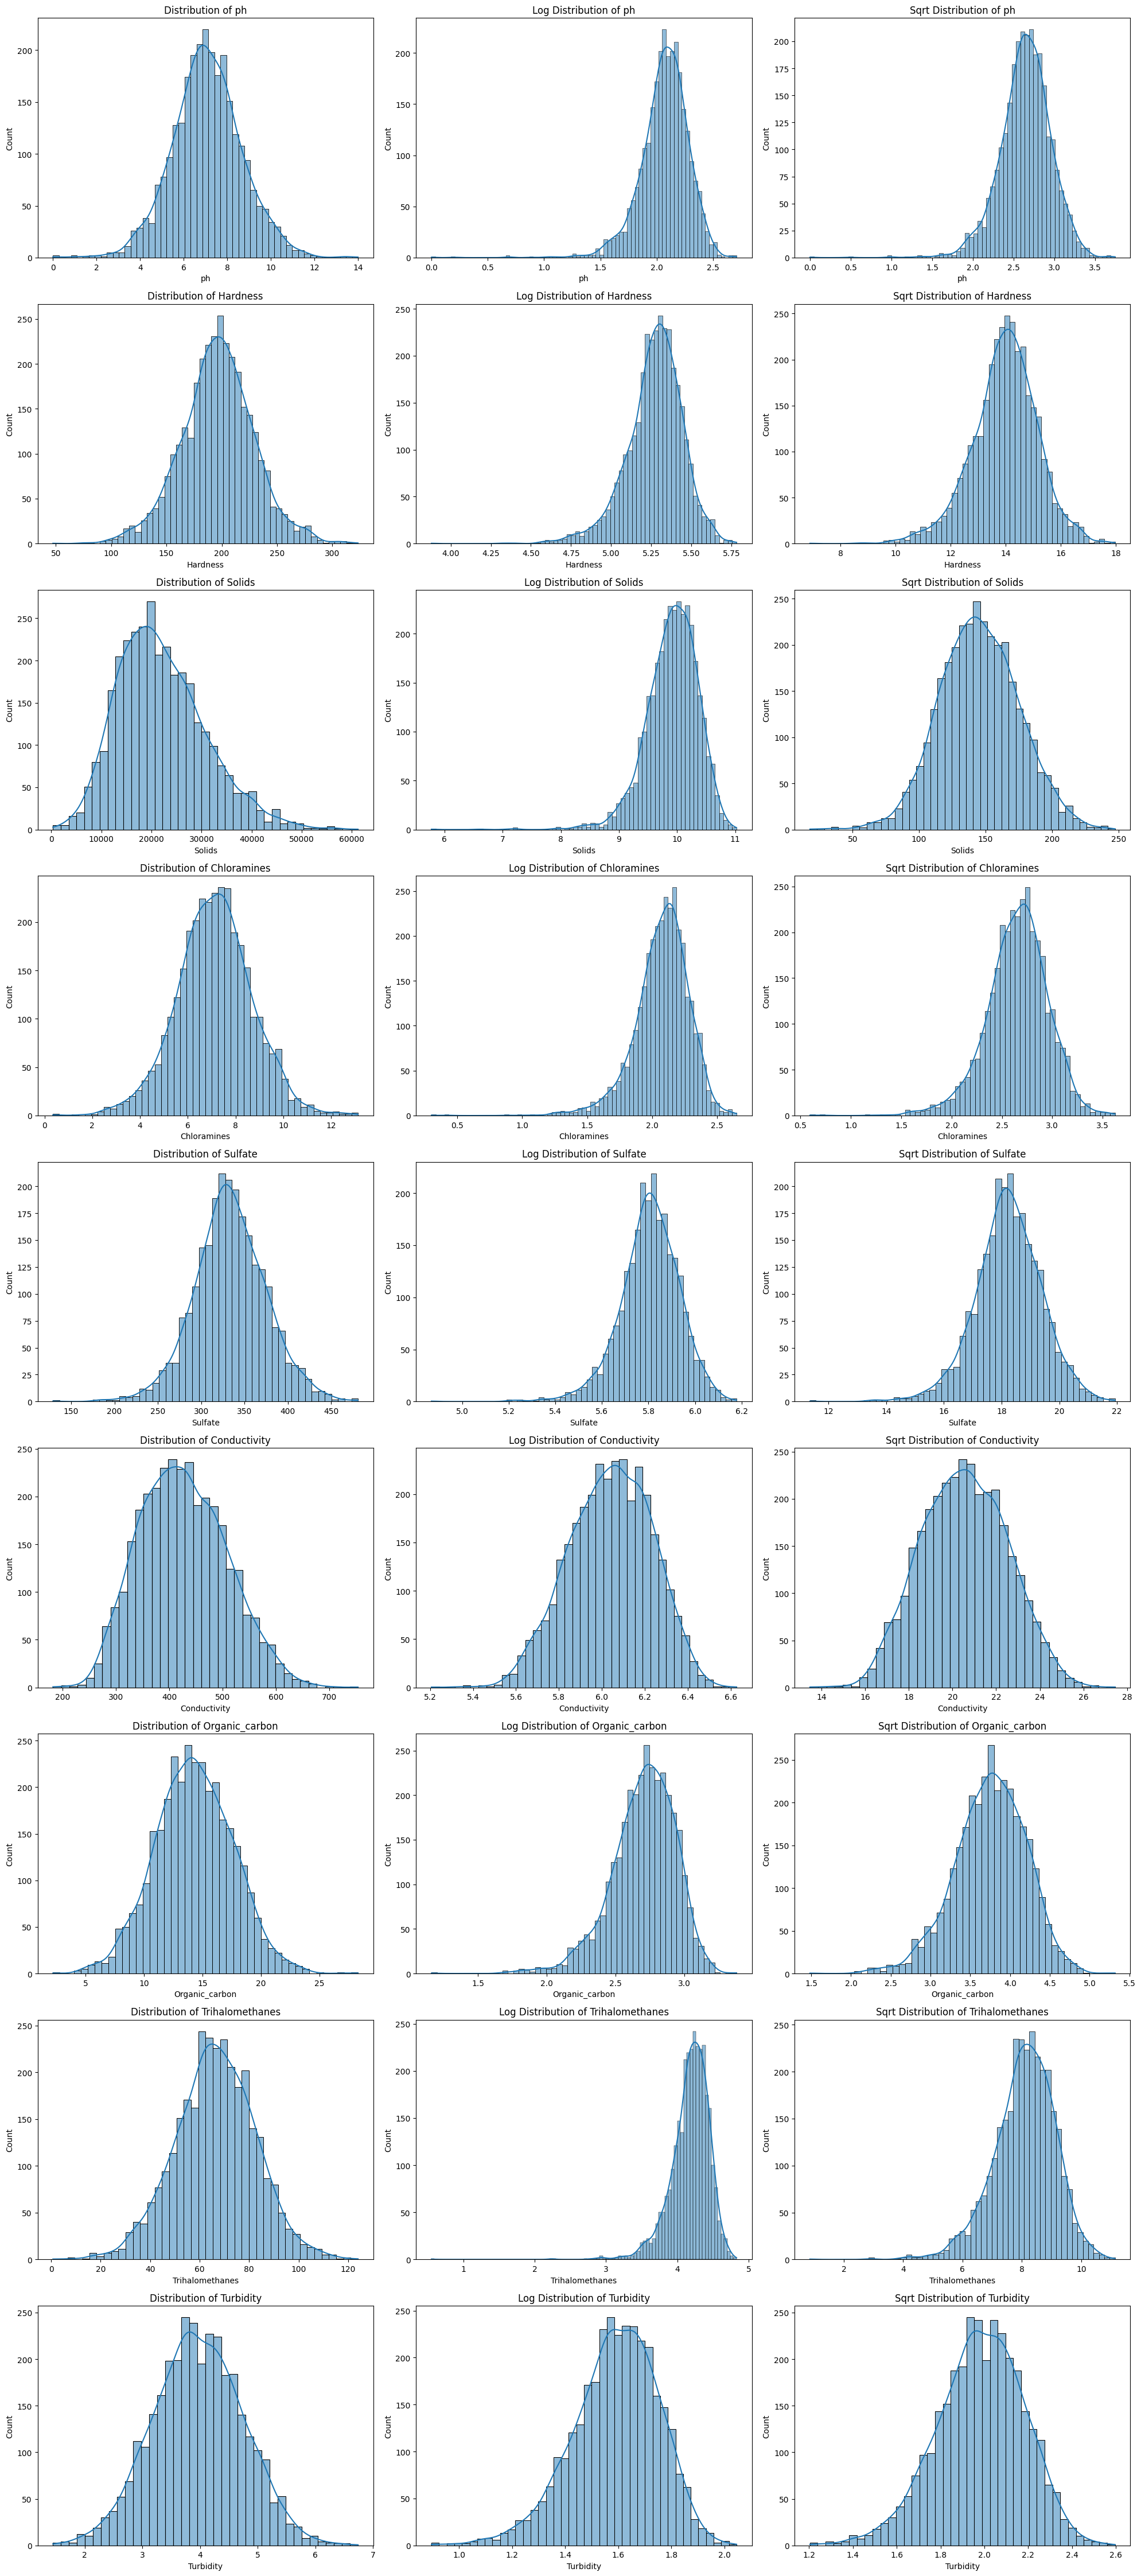

In [76]:
features = df.columns[:-1]

fig, axes = plt.subplots(nrows=len(features), ncols=3, figsize=(20, 45))

for i,feature in enumerate(features):
    sns.histplot(x=df[feature], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"Distribution of {feature}")

    sns.histplot(x=np.log1p(df[feature]), kde=True, ax=axes[i, 1])
    axes[i, 1].set_title(f"Log Distribution of {feature}")

    sns.histplot(x=np.sqrt(df[feature]), kde=True, ax=axes[i, 2])
    axes[i, 2].set_title(f"Sqrt Distribution of {feature}")

plt.tight_layout()
plt.show()

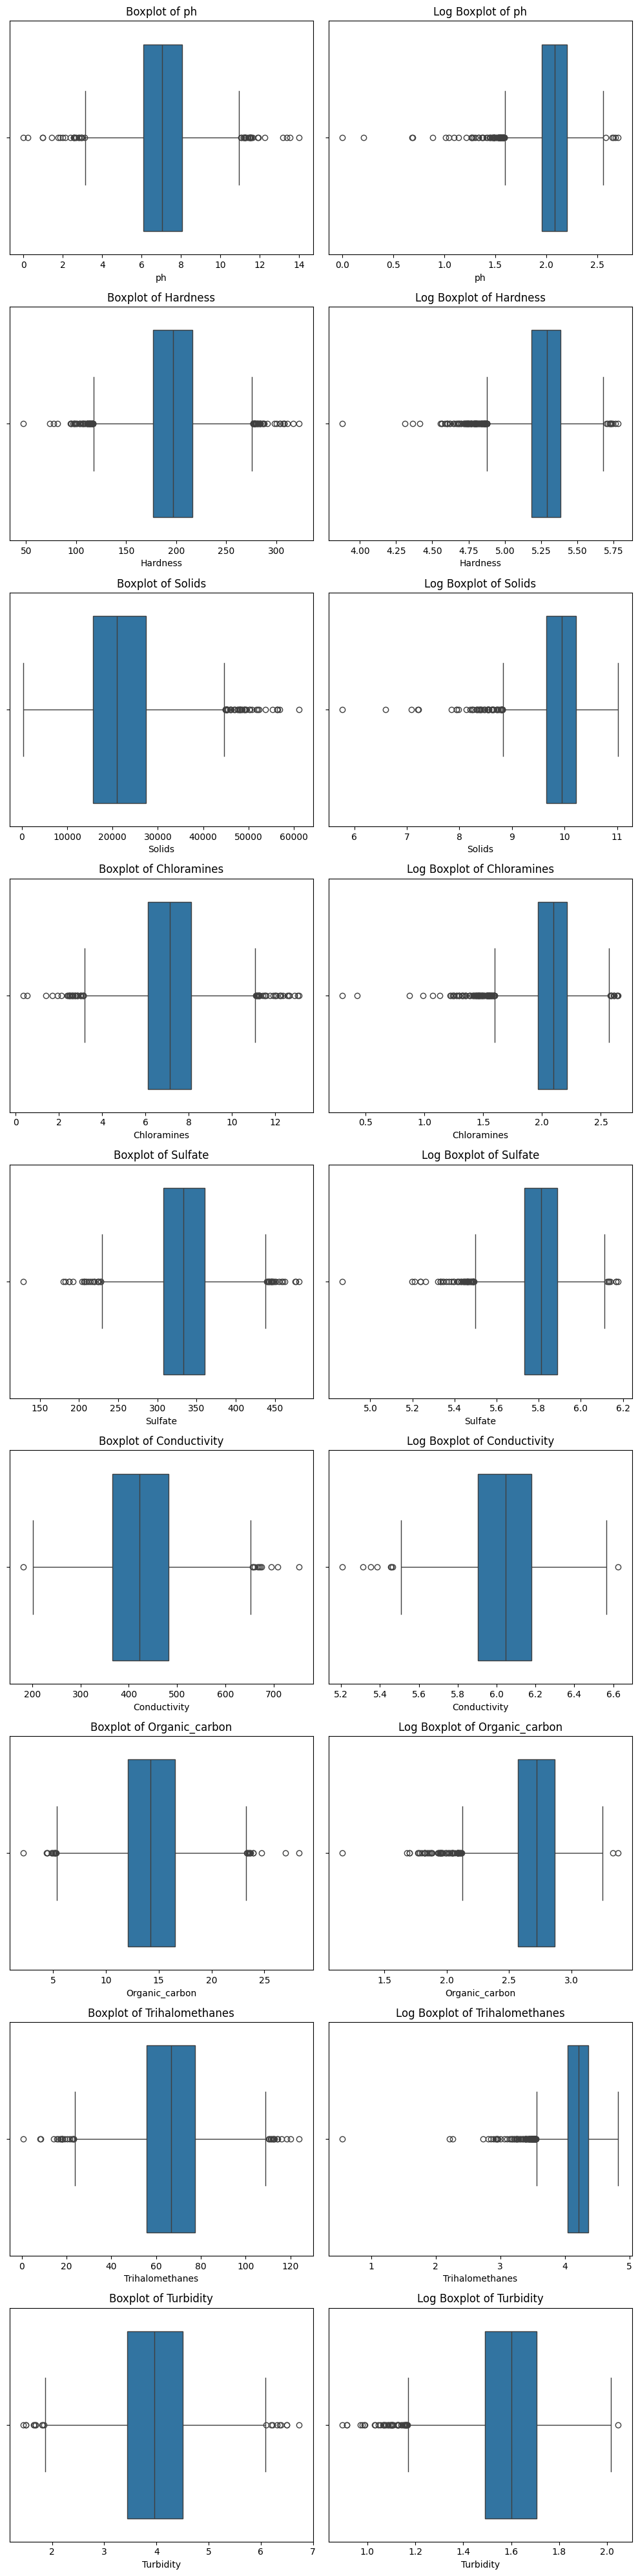

In [77]:
fig, axes = plt.subplots(nrows=len(features), ncols=2, figsize=(10, 40))

for i,feature in enumerate(features):
    sns.boxplot(x=df[feature], ax=axes[i, 0])
    axes[i, 0].set_title(f"Boxplot of {feature}")

    sns.boxplot(x=np.log1p(df[feature]), ax=axes[i, 1])
    axes[i, 1].set_title(f"Log Boxplot of {feature}")

plt.tight_layout()
plt.show()

## Observations of Univariate Analysis

### Histograms

- All features are distributed along a bell curve, thereby requiring no transformation
- **Solids** is slightly right skewed, which can be fixed using sqrt transformation
- **Log Transformation** is generally avoided as it introduces left skewness in the histograms

### Boxplots

- In regular boxplots, the median roughly sits in the middle of the IQR
- Log Boxplots tend to shift the median towards the right, which is already shown by the log distributions

### Overall Conclusion

- Log transformation is to be avoided as it introduces left skewness

## Bivariate Analysis

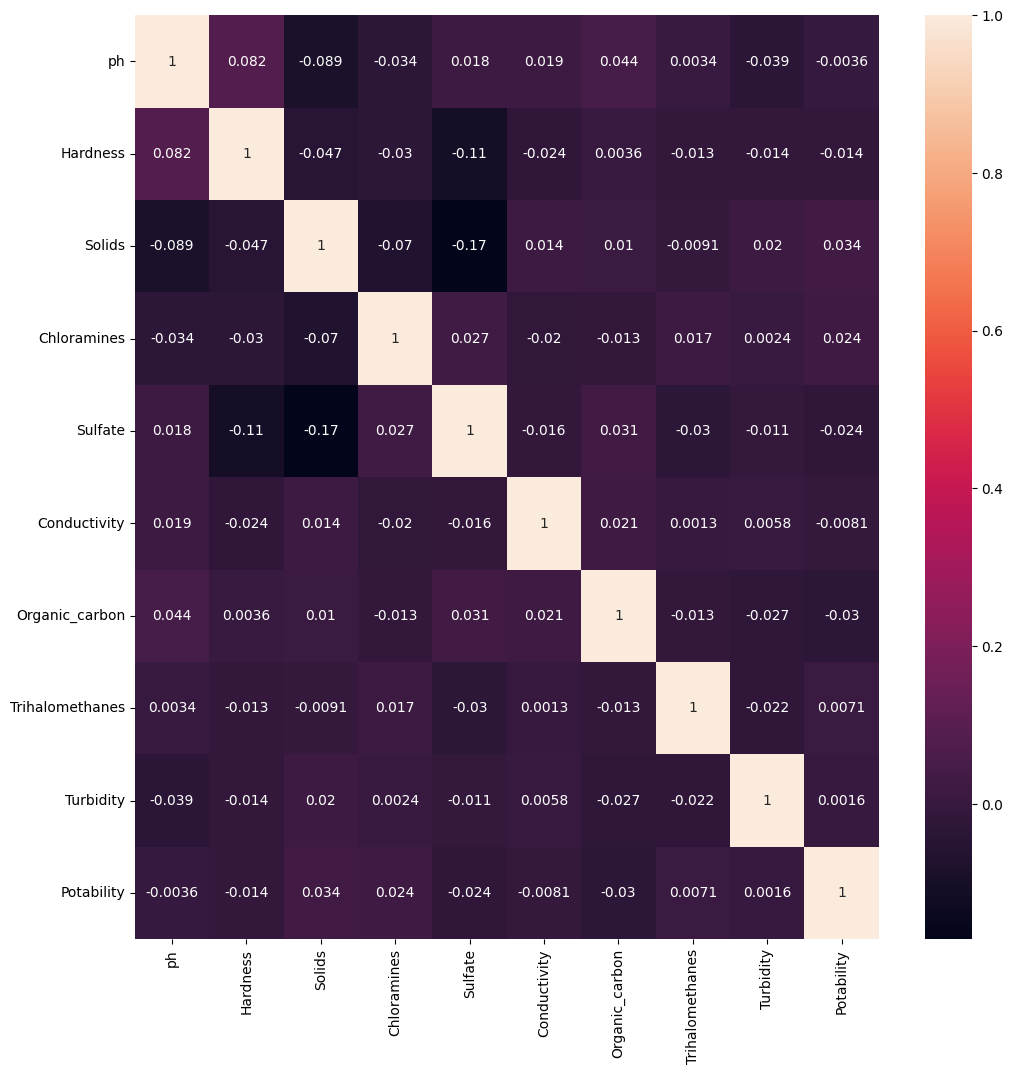

In [83]:
corr = df.corr()
plt.figure(figsize=(12, 12))
sns.heatmap(corr, annot=True)
plt.show()

## Observations of Bivariate Analysis

### HeatMap

- The heatmap doesn't show any strong correlations of the features with **Potability**
- No issue of multicollinearity as the independent features show weak correlations

### Overall Observation

- No linear relationships present
- Lack of Multicollinearity